In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize, linprog

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})

TOTAL_UNITS = 33_000
MIN_UNITS_PER_LSOA = 6

In [102]:
CRIME_DATA_PATH = "../.cache/crime-data"

pds = []
year = 2025
for month in range(1, 12 + 1):
    try:
        pds.append(
            pd.read_csv(
                f"{CRIME_DATA_PATH}/{year:04}-{month:02}.csv"
            )
        )
    except:
        pass

df_raw = (
    pd.concat(pds)
    .groupby(
        ["lsoa_code", "lsoa_name", "borough", "category", "year"]
    )["crime_count"]
    .sum()
    .reset_index()
)

print(f"Total incidents: {df_raw["crime_count"].sum():,}")

df_raw.head()

Total incidents: 944,589


,lsoa_code,lsoa_name,borough,category,year,crime_count
0,E01000001,City of London 001A,City of London,anti-social-behaviour,2025,11
1,E01000001,City of London 001A,City of London,bicycle-theft,2025,21
2,E01000001,City of London 001A,City of London,burglary,2025,7
3,E01000001,City of London 001A,City of London,criminal-damage-arson,2025,13
4,E01000001,City of London 001A,City of London,drugs,2025,11


In [103]:
SEVERITY_WEIGHTS = {
    'violent-crime':           10.0,
    'robbery':                  8.0,
    'burglary':                 6.0,
    'theft-from-the-person':    4.0,
    'vehicle-crime':            3.0,
    'other-theft':              2.5,
    'shoplifting':              1.5,
    'bicycle-theft':            1.5,
    'criminal-damage-arson':    4.0,
    'other-crime':              2.0,
    'anti-social-behaviour':    1.5,
    'public-order':             1.0,
    'drugs':                    0.8,
    'possession-of-weapons':    3.0,
}

df_raw["severity_score"] = df_raw["category"].map(SEVERITY_WEIGHTS) * df_raw["crime_count"]

lsoa_df = (
    df_raw.groupby(["lsoa_code", "lsoa_name", "borough"])
    .agg(
        total_crimes = ("crime_count", "sum"),
        severity_score = ("severity_score", "sum"),
        crime_types = ("category", "nunique"),
    )
    .reset_index()
    .sort_values("severity_score", ascending=False)
    .reset_index(drop=True)
)

TOTAL_CRIME = lsoa_df["total_crimes"].sum()
lsoa_df["crime_share"] = lsoa_df["total_crimes"] / TOTAL_CRIME

lsoa_df.head(10).style.background_gradient(subset=["severity_score", "total_crimes"], cmap="YlOrRd")

,lsoa_code,lsoa_name,borough,total_crimes,severity_score,crime_types,crime_share
0,E01004763,Westminster 013B,Westminster,8398,33887.300000,14,0.008891
1,E01033595,Westminster 013E,Westminster,9052,32474.500000,14,0.009583
2,E01004734,Westminster 018A,Westminster,7438,30752.900000,14,0.007874
3,E01032739,City of London 001F,City of London,5573,22709.300000,14,0.005900
4,E01004736,Westminster 018C,Westminster,4897,20370.900000,14,0.005184
5,E01033583,Newham 013G,Newham,5053,18033.000000,14,0.005349
6,E01002444,Hillingdon 031A,Hillingdon,5030,16501.000000,14,0.005325
7,E01004714,Westminster 011B,Westminster,3557,11946.300000,14,0.003766
8,E01002968,Kingston upon Thames 009C,Kingston upon Thames,3277,11343.100000,14,0.003469
9,E01004735,Westminster 018B,Westminster,2893,9844.800000,14,0.003063


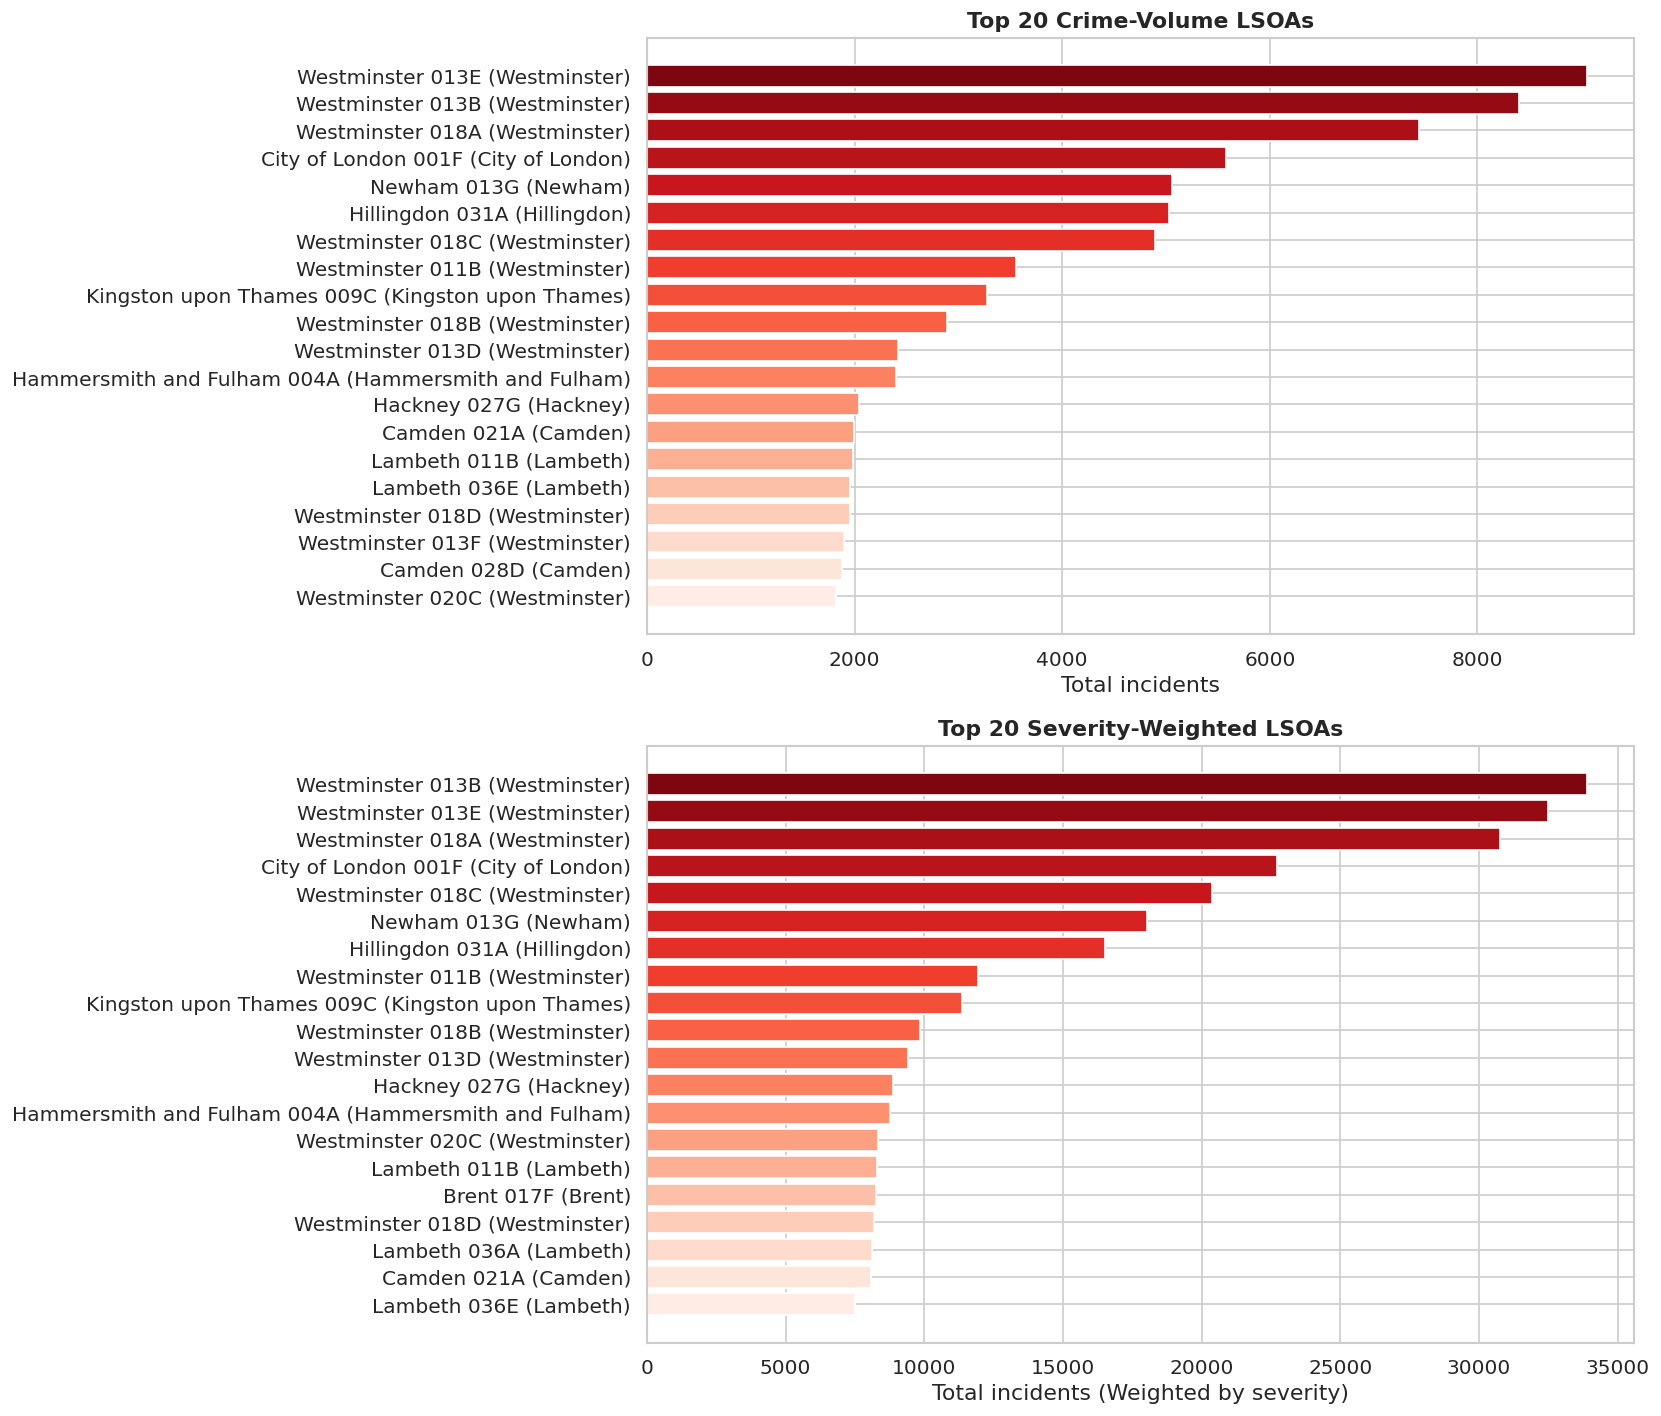

In [104]:
df_top20_volume = (
    df_raw.groupby(["lsoa_code", "lsoa_name", "borough"])["crime_count"]
    .sum()
    .reset_index()
    .sort_values("crime_count", ascending=False)
    .head(20)
)

df_top20_weighted = (
    df_raw.groupby(["lsoa_code", "lsoa_name", "borough"])["severity_score"]
    .sum()
    .reset_index()
    .sort_values("severity_score", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(2, 1, figsize=(14, 12))
bars = ax[0].barh(
    df_top20_volume["lsoa_name"] + " (" + df_top20_volume["borough"] + ")",
    df_top20_volume["crime_count"],
    color=sns.color_palette("Reds_r", 20)
)
ax[0].set_title("Top 20 Crime-Volume LSOAs", fontweight="bold")
ax[0].set_xlabel("Total incidents")
ax[0].invert_yaxis()

bars = ax[1].barh(
    df_top20_weighted["lsoa_name"] + " (" + df_top20_weighted["borough"] + ")",
    df_top20_weighted["severity_score"],
    color=sns.color_palette("Reds_r", 20)
)
ax[1].set_title("Top 20 Severity-Weighted LSOAs", fontweight="bold")
ax[1].set_xlabel("Total incidents (Weighted by severity)")
ax[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [105]:
def naive_baseline(df: pd.DataFrame, total_units: float) -> pd.DataFrame:
    result = df[["lsoa_code", "lsoa_name", "borough", "total_crimes", "crime_share"]].copy()
    result["allocated_units"] = result["crime_share"] * total_units
    return result

baseline_df = naive_baseline(lsoa_df, TOTAL_UNITS)

baseline_df.sort_values("allocated_units", ascending=False).head(10)

,lsoa_code,lsoa_name,borough,total_crimes,crime_share,allocated_units
1,E01033595,Westminster 013E,Westminster,9052,0.009583,316.239126
0,E01004763,Westminster 013B,Westminster,8398,0.008891,293.391094
2,E01004734,Westminster 018A,Westminster,7438,0.007874,259.852698
3,E01032739,City of London 001F,City of London,5573,0.005900,194.697376
5,E01033583,Newham 013G,Newham,5053,0.005349,176.530745
6,E01002444,Hillingdon 031A,Hillingdon,5030,0.005325,175.727221
4,E01004736,Westminster 018C,Westminster,4897,0.005184,171.080756
7,E01004714,Westminster 011B,Westminster,3557,0.003766,124.266745
8,E01002968,Kingston upon Thames 009C,Kingston upon Thames,3277,0.003469,114.484712
9,E01004735,Westminster 018B,Westminster,2893,0.003063,101.069354


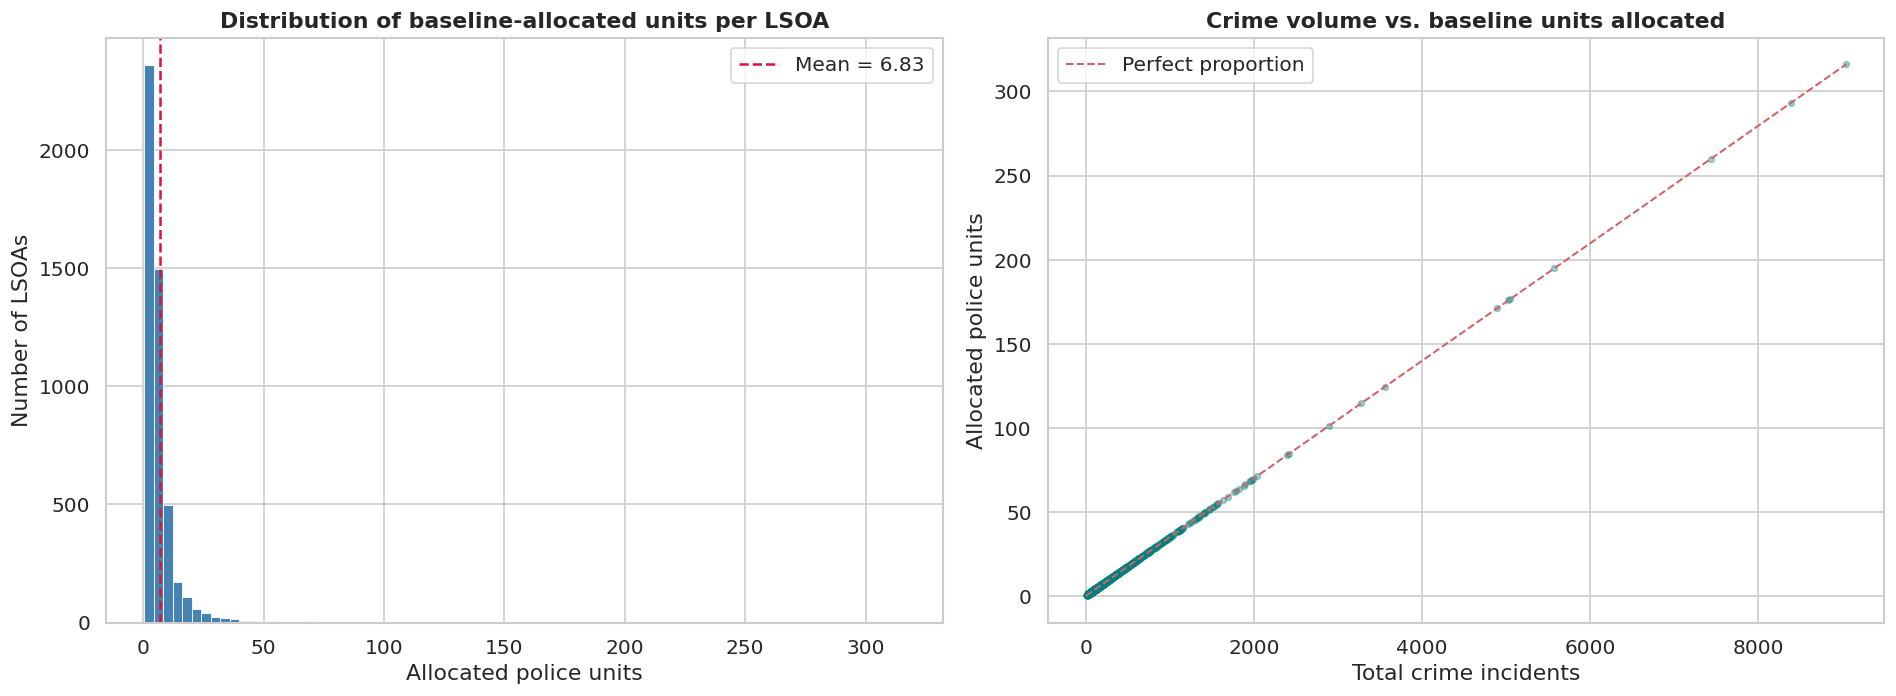

In [106]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].hist(baseline_df["allocated_units"], bins=80, color="steelblue", edgecolor="white", linewidth=0.5)
ax[0].set_title("Distribution of baseline-allocated units per LSOA", fontweight="bold")
ax[0].set_xlabel("Allocated police units")
ax[0].set_ylabel("Number of LSOAs")
ax[0].axvline(baseline_df["allocated_units"].mean(), color="crimson", linestyle="--", label=f"Mean = {baseline_df["allocated_units"].mean():.2f}")
ax[0].legend()

ax[1].scatter(baseline_df["total_crimes"], baseline_df["allocated_units"], alpha=0.35, s=12, color="teal")
ax[1].set_title("Crime volume vs. baseline units allocated", fontweight="bold")
ax[1].set_xlabel("Total crime incidents")
ax[1].set_ylabel("Allocated police units")
x_max = baseline_df["total_crimes"].max()
slope = TOTAL_UNITS / TOTAL_CRIME
ax[1].plot([0, x_max], [0, x_max * slope], "r--", linewidth=1.2, label="Perfect proportion")
ax[1].legend()

plt.tight_layout()
plt.show()

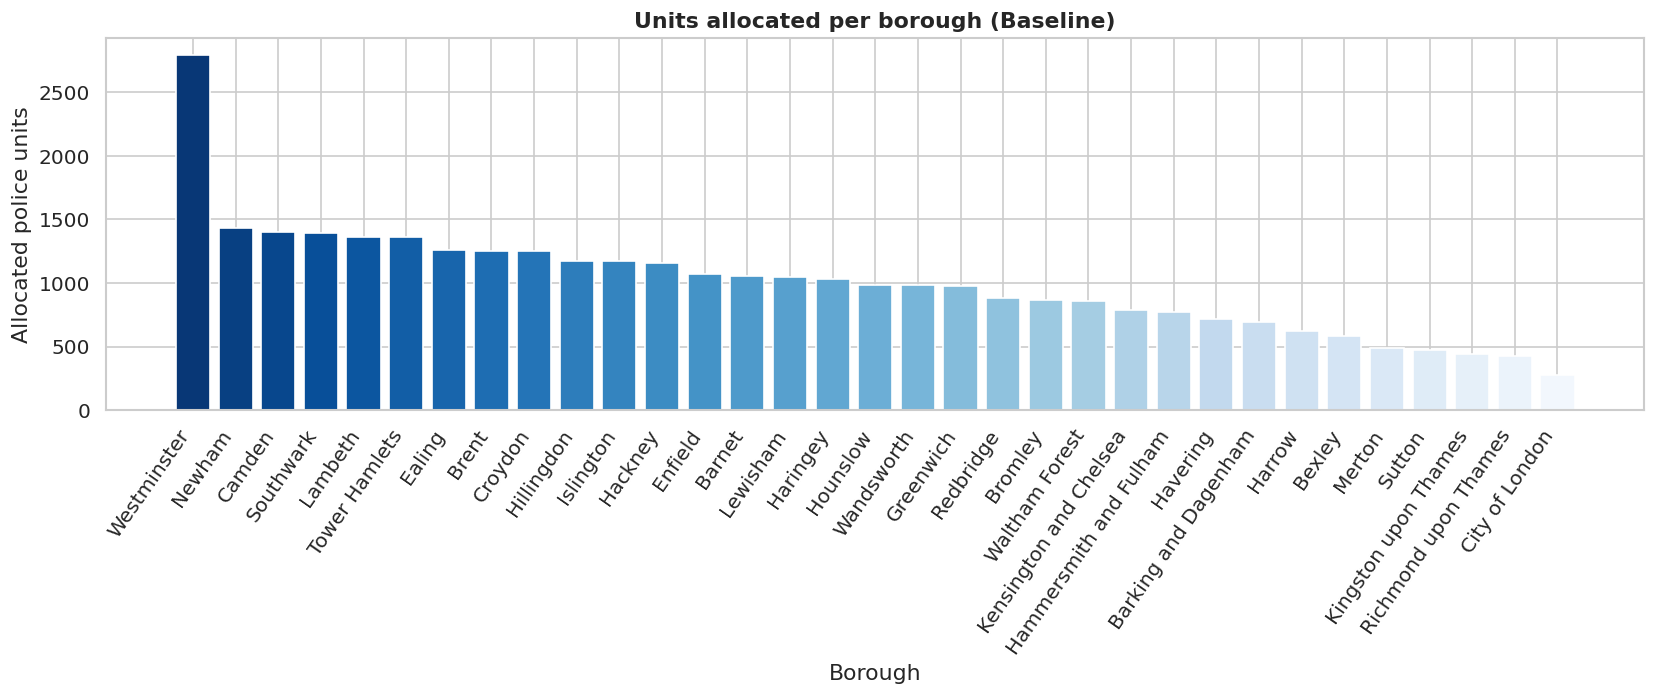

In [107]:
bor_baseline = (
    baseline_df.groupby("borough")
    .agg(total_crimes=("total_crimes", "sum"),
         allocated_units=("allocated_units", "sum"),
         n_lsoas=("lsoa_code", "count"))
    .sort_values("allocated_units", ascending=False)
    .reset_index()
)
bor_baseline["units_per_lsoa"] = bor_baseline["allocated_units"] / bor_baseline["n_lsoas"]

fig, ax = plt.subplots(figsize=(14, 6))
colors = sns.color_palette("Blues_r", len(bor_baseline))
ax.bar(bor_baseline["borough"], bor_baseline["allocated_units"], color=colors)
ax.set_title("Units allocated per borough (Baseline)", fontweight="bold")
ax.set_ylabel("Allocated police units")
ax.set_xlabel("Borough")

plt.xticks(rotation=55, ha="right")
plt.tight_layout()
plt.show()

In [108]:
baseline_df = naive_baseline(lsoa_df, TOTAL_UNITS)
lsoa_df = lsoa_df.merge(
    baseline_df[["lsoa_code", "allocated_units"]],
    on="lsoa_code", how="left"
)

In [109]:
α = 0.6
β = 0.25
γ = 0.15

MIN_UNITS_LP = MIN_UNITS_PER_LSOA
MAX_CAP_FACTOR = 3.5

EQUITY_FLOOR = 0.7

In [110]:
import time

n_lsoas = len(lsoa_df)
s = lsoa_df["severity_score"].values
c_crimes = lsoa_df["total_crimes"].values
ct = lsoa_df["crime_types"].values
TOTAL_SEV = s.sum()
MAX_CT = ct.max()

diversity = ct / MAX_CT

c_obj = -(
    α * s / TOTAL_SEV + β * c_crimes / TOTAL_CRIME + γ * diversity / (diversity.sum() / n_lsoas)
)

sev_proportional = (s / TOTAL_SEV) * TOTAL_UNITS
upper_bounds = np.maximum(float(MIN_UNITS_LP), MAX_CAP_FACTOR * sev_proportional)
bounds_lp = [(float(MIN_UNITS_LP), float(ub)) for ub in upper_bounds]

boroughs = lsoa_df["borough"].unique()
borough_crime_sum = lsoa_df.groupby("borough")["total_crimes"].sum()

A_eq_lp = np.ones((1, n_lsoas))
b_eq_lp = np.array([float(TOTAL_UNITS)])
A_ub_lp = []
b_ub_lp = []

for borough in boroughs:
    mask = (lsoa_df["borough"] == borough).values
    bor_share = borough_crime_sum[borough] / TOTAL_CRIME
    floor = EQUITY_FLOOR * bor_share * TOTAL_UNITS
    A_ub_lp.append(-mask.astype(float))
    b_ub_lp.append(-floor)

A_ub_lp = np.array(A_ub_lp)
b_ub_lp = np.array(b_ub_lp)

res = linprog(
    c_obj,
    A_ub=A_ub_lp, b_ub=b_ub_lp,
    A_eq=A_eq_lp, b_eq=b_eq_lp,
    bounds=bounds_lp,
    method="highs",
    options={"disp": False},
)

lsoa_df["lp_units"] = res.x

lsoa_df.head(10)

,lsoa_code,lsoa_name,borough,total_crimes,severity_score,crime_types,crime_share,allocated_units,lp_units
0,E01004763,Westminster 013B,Westminster,8398,33887.3,14,0.008891,293.391094,960.090234
1,E01033595,Westminster 013E,Westminster,9052,32474.5,14,0.009583,316.239126,920.062982
2,E01004734,Westminster 018A,Westminster,7438,30752.9,14,0.007874,259.852698,871.286852
3,E01032739,City of London 001F,City of London,5573,22709.3,14,0.005900,194.697376,643.396704
4,E01004736,Westminster 018C,Westminster,4897,20370.9,14,0.005184,171.080756,269.118052
5,E01033583,Newham 013G,Newham,5053,18033.0,14,0.005349,176.530745,37.881053
6,E01002444,Hillingdon 031A,Hillingdon,5030,16501.0,14,0.005325,175.727221,6.000000
7,E01004714,Westminster 011B,Westminster,3557,11946.3,14,0.003766,124.266745,6.000000
8,E01002968,Kingston upon Thames 009C,Kingston upon Thames,3277,11343.1,14,0.003469,114.484712,6.000000
9,E01004735,Westminster 018B,Westminster,2893,9844.8,14,0.003063,101.069354,6.000000


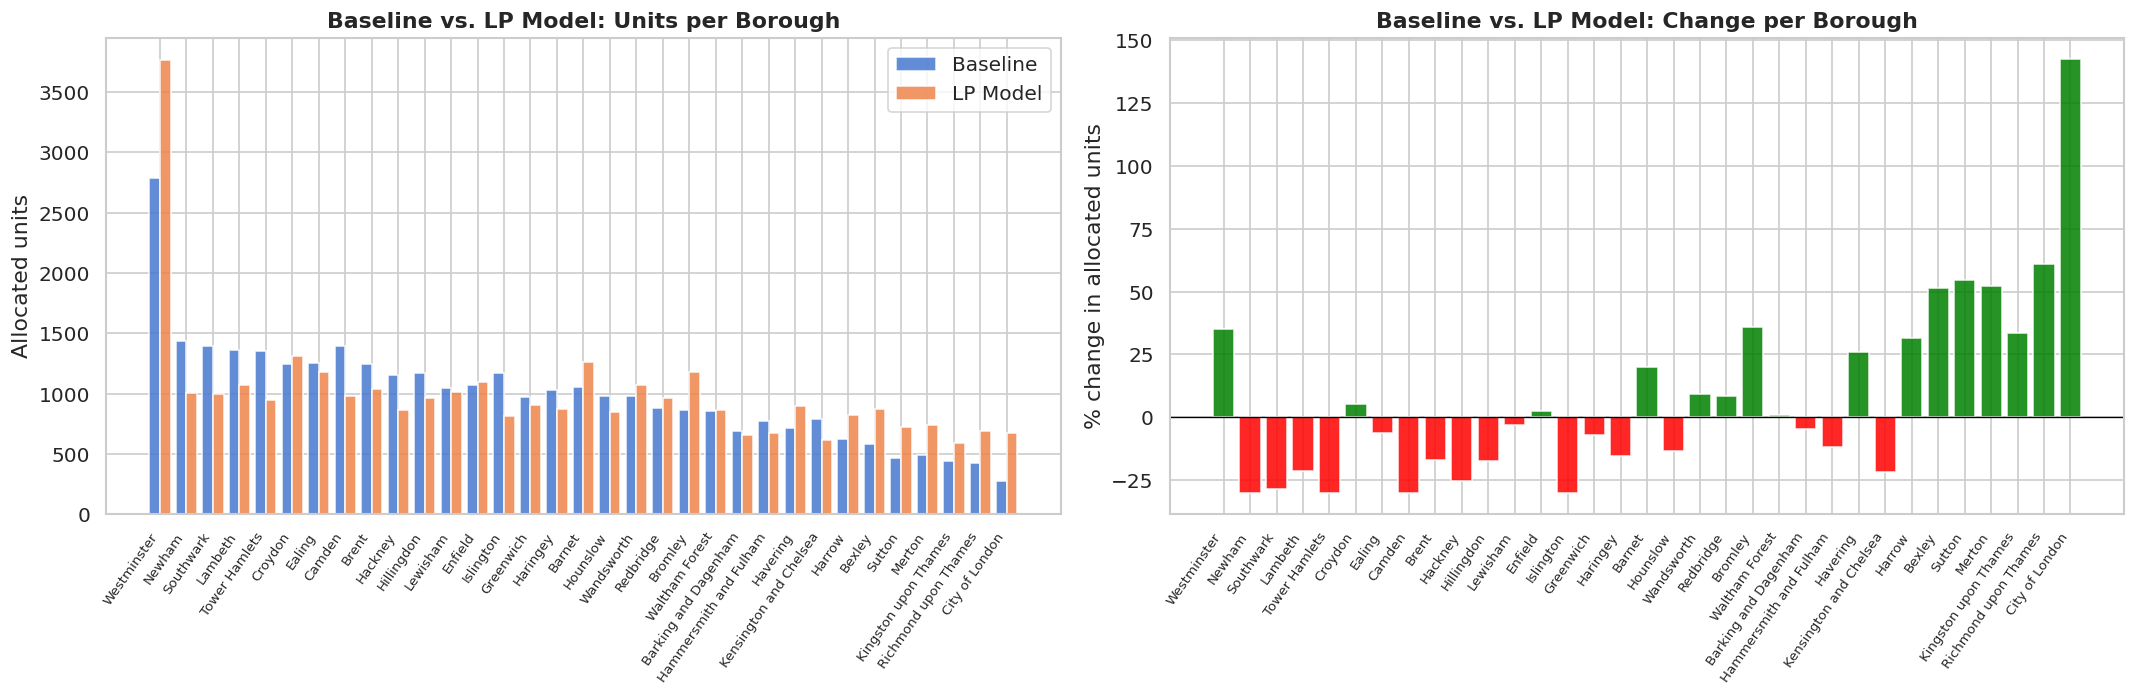

In [111]:
lsoa_df["bl_units"] = lsoa_df["allocated_units"]

bor_cmp = (
    lsoa_df
    .groupby("borough")
    .agg(
        bl_units = ("bl_units", "sum"),
        lp_units = ("lp_units", "sum"),
        total_crimes = ("total_crimes", "sum"),
        severity_score = ("severity_score", "sum"),
    )
    .sort_values("severity_score", ascending=False)
    .reset_index()
)
bor_cmp["lp_vs_bl_pct"] = (bor_cmp["lp_units"] / bor_cmp["bl_units"] - 1) * 100

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

x = np.arange(len(bor_cmp))
w = 0.4
ax[0].bar(x - w / 2, bor_cmp["bl_units"], w, label="Baseline", alpha=0.85)
ax[0].bar(x + w / 2, bor_cmp["lp_units"], w, label="LP Model", alpha=0.85)
ax[0].set_xticks(x)
ax[0].set_xticklabels(bor_cmp["borough"], rotation=55, ha="right", fontsize=8)
ax[0].set_title("Baseline vs. LP Model: Units per Borough", fontweight="bold")
ax[0].set_ylabel("Allocated units")
ax[0].legend()

colors = ["red" if v < 0 else "green" for v in bor_cmp["lp_vs_bl_pct"]]
ax[1].bar(x, bor_cmp["lp_vs_bl_pct"], color=colors, alpha=0.85)
ax[1].axhline(0, color="black", lw=0.8)
ax[1].set_xticks(x)
ax[1].set_xticklabels(bor_cmp["borough"], rotation=55, ha="right", fontsize=8)
ax[1].set_title("Baseline vs. LP Model: Change per Borough", fontweight="bold")
ax[1].set_ylabel("% change in allocated units")

plt.tight_layout()
plt.show()

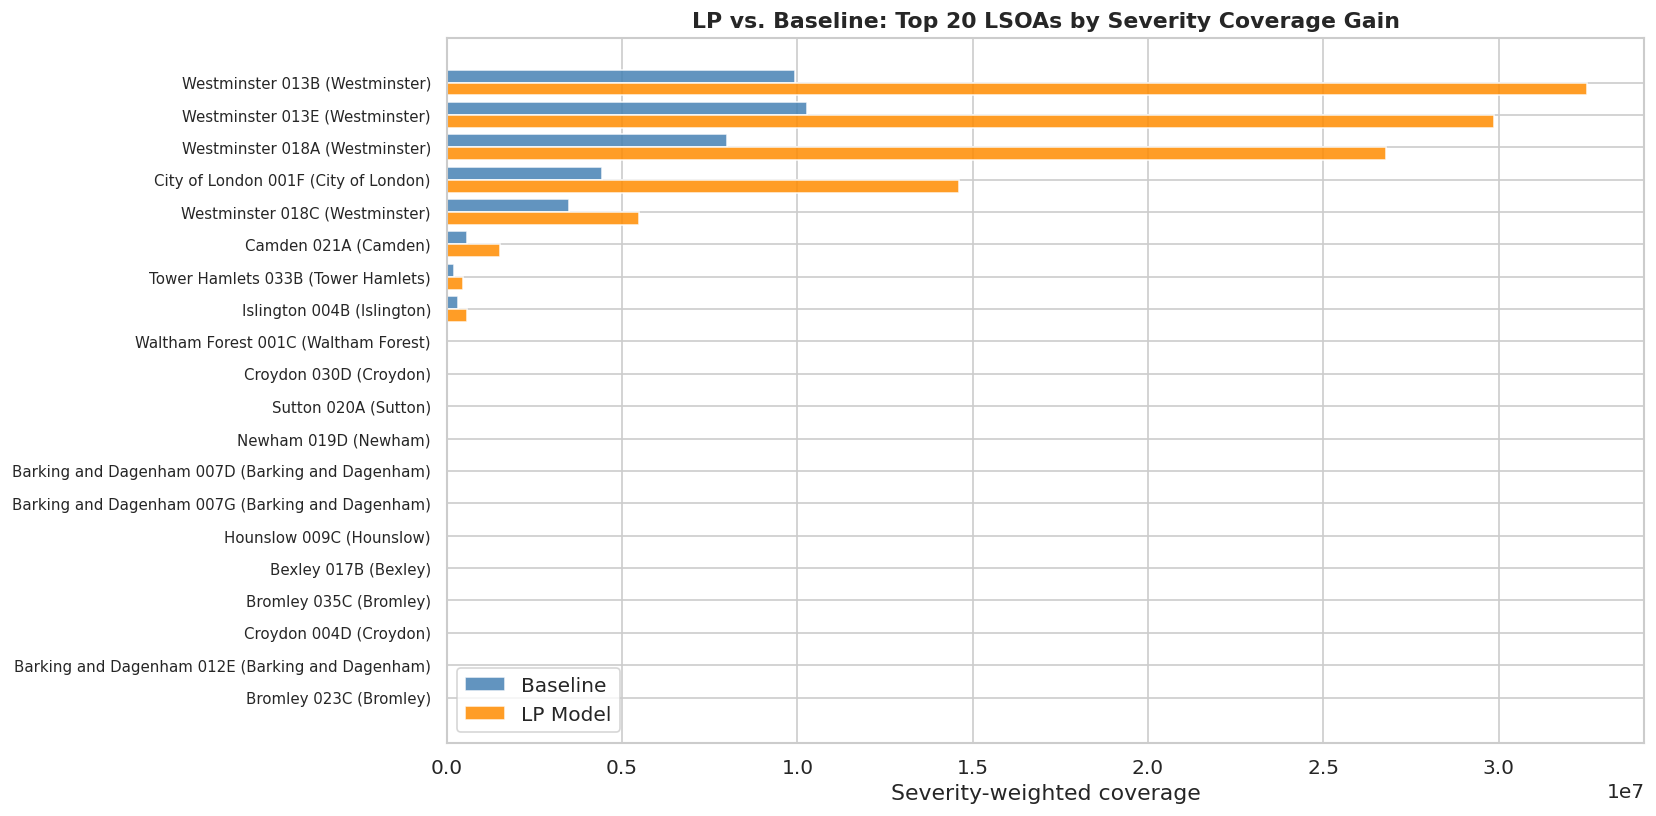

In [112]:
lsoa_df["sev_coverage_baseline"] = s * lsoa_df["bl_units"]
lsoa_df["sev_coverage_lp"]       = s * lsoa_df["lp_units"]
lsoa_df["sev_gain"]              = lsoa_df["sev_coverage_lp"] - lsoa_df["sev_coverage_baseline"]

top20 = lsoa_df.nlargest(20, "sev_gain")

fig, ax = plt.subplots(figsize=(14, 7))
y = np.arange(len(top20))
ax.barh(y - 0.2, top20["sev_coverage_baseline"], 0.4, label="Baseline", color="steelblue", alpha=0.85)
ax.barh(y + 0.2, top20["sev_coverage_lp"], 0.4, label="LP Model", color="darkorange", alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(top20["lsoa_name"] + " (" + top20["borough"] + ")", fontsize=9)
ax.invert_yaxis()
ax.set_title("LP vs. Baseline: Top 20 LSOAs by Severity Coverage Gain", fontweight="bold")
ax.set_xlabel("Severity-weighted coverage")
ax.legend()
plt.tight_layout()
plt.show()

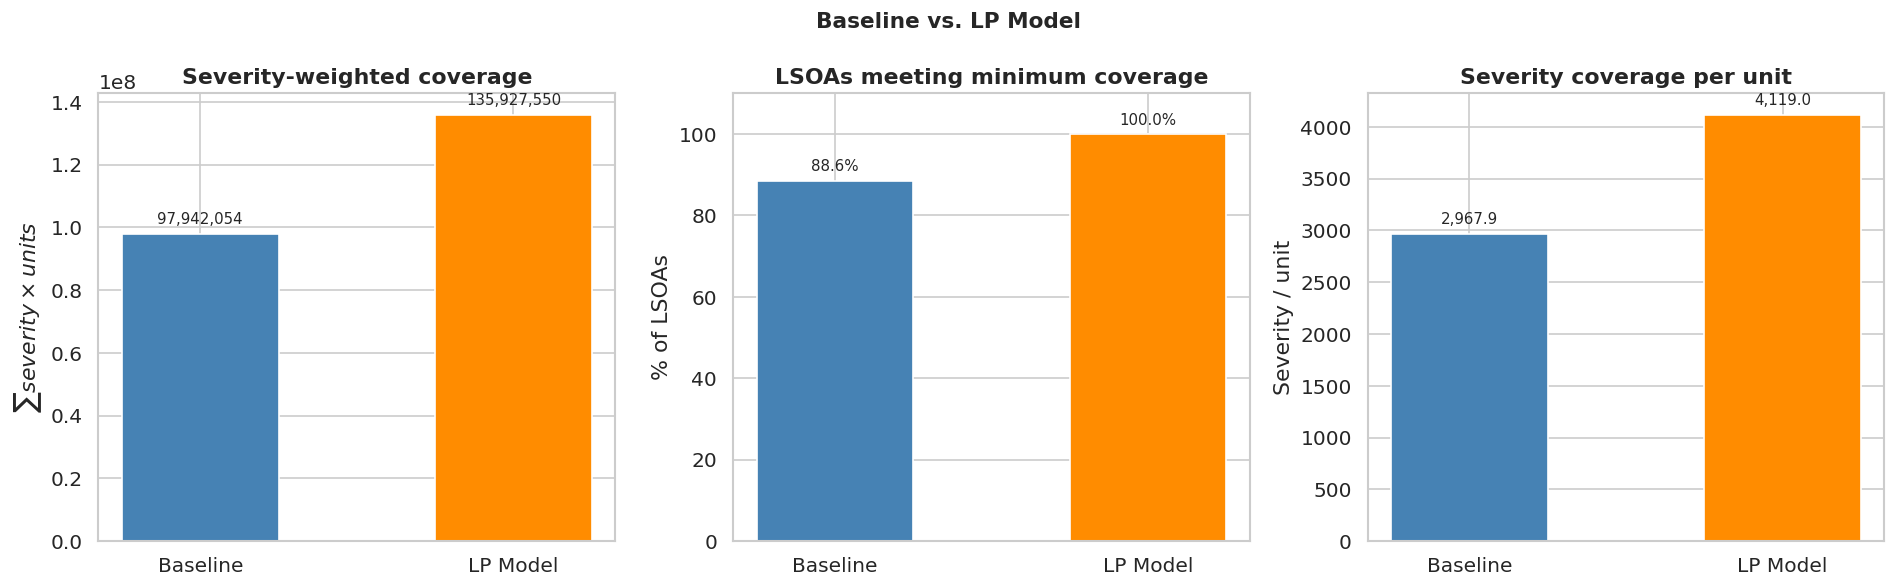

In [113]:
def severity_coverage(alloc, severity) -> float:
    return (severity * alloc).sum()

def min_coverage_rate(alloc, threshold = 2.0) -> float:
    return (alloc >= threshold).mean()

def severity_per_unit(alloc, severity) -> float:
    return (severity * alloc).sum() / alloc.sum()

fig, ax = plt.subplots(1, 3, figsize=(16, 5))

bl_units = lsoa_df["bl_units"]
lp_units = lsoa_df["lp_units"]

models = ["Baseline", "LP Model"]
sev_vals = [severity_coverage(bl_units, s), severity_coverage(lp_units, s)]
bars = ax[0].bar(models, sev_vals, color=["steelblue", "darkorange"], width=0.5)
ax[0].bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=9)
ax[0].set_title("Severity-weighted coverage", fontweight="bold")
ax[0].set_ylabel("$\\sum severity \\times units$")

cov_vals = [min_coverage_rate(bl_units) * 100, min_coverage_rate(lp_units) * 100]
bars = ax[1].bar(models, cov_vals, color=["steelblue", "darkorange"], width=0.5)
ax[1].bar_label(bars, fmt="{:.1f}%", padding=4, fontsize=9)
ax[1].set_ylim(0, 110)
ax[1].set_title("LSOAs meeting minimum coverage", fontweight="bold")
ax[1].set_ylabel("% of LSOAs")

eff_vals = [severity_per_unit(bl_units, s), severity_per_unit(lp_units, s)]
bars = ax[2].bar(models, eff_vals, color=["steelblue", "darkorange"], width=0.5)
ax[2].bar_label(bars, fmt="{:,.1f}", padding=4, fontsize=9)
ax[2].set_title("Severity coverage per unit", fontweight="bold")
ax[2].set_ylabel("Severity / unit")

plt.suptitle("Baseline vs. LP Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [114]:
n_r = len(lsoa_df)
s_r = lsoa_df["severity_score"].values
total_sev_r = s_r.sum()

sev_entitlement = (s_r / total_sev_r) * TOTAL_UNITS

c_r = np.zeros(n_r + 1)
c_r[-1] = -1.0

bounds_r = [(MIN_UNITS_PER_LSOA, None)] * n_r + [(0.0, 1.0)]

A_eq_r = np.zeros((1, n_r + 1))
A_eq_r[0, :n_r] = 1.0
b_eq_r = np.array([TOTAL_UNITS])

A_ub_r = np.zeros((n_r, n_r + 1))
for i in range(n_r):
    A_ub_r[i, i] = -1.0
    A_ub_r[i, -1] = sev_entitlement[i]
b_ub_r = np.zeros(n_r)

res_r = linprog(c_r, A_ub=A_ub_r, b_ub=b_ub_r, A_eq=A_eq_r, b_eq=b_eq_r, bounds=bounds_r, method="highs")

lsoa_df["r_units"] = res_r.x[:n_r]

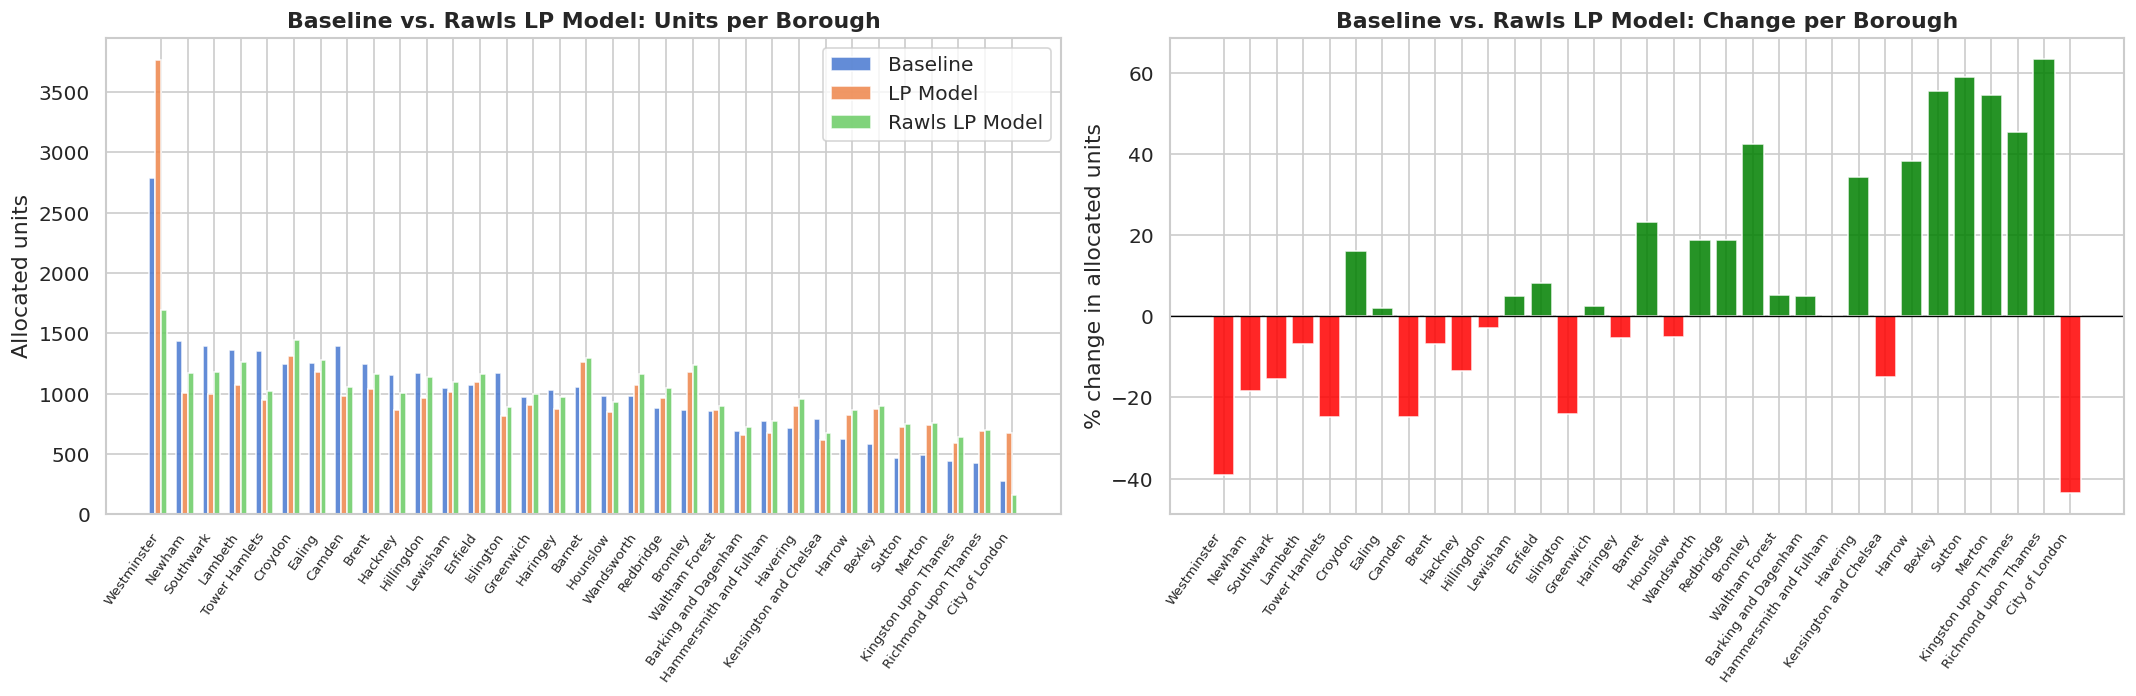

In [115]:
lsoa_df["bl_units"] = lsoa_df["allocated_units"]

bor_cmp = (
    lsoa_df
    .groupby("borough")
    .agg(
        bl_units = ("bl_units", "sum"),
        lp_units = ("lp_units", "sum"),
        r_units = ("r_units", "sum"),
        total_crimes = ("total_crimes", "sum"),
        severity_score = ("severity_score", "sum"),
    )
    .sort_values("severity_score", ascending=False)
    .reset_index()
)
bor_cmp["r_vs_bl_pct"] = (bor_cmp["r_units"] / bor_cmp["bl_units"] - 1) * 100

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

x = np.arange(len(bor_cmp))
w = 0.22
ax[0].bar(x - 1.5 * w, bor_cmp["bl_units"], w, label="Baseline", alpha=0.85)
ax[0].bar(x + w - 1.5 * w, bor_cmp["lp_units"], w, label="LP Model", alpha=0.85)
ax[0].bar(x + 2 * w - 1.5 * w, bor_cmp["r_units"], w, label="Rawls LP Model", alpha=0.85)
ax[0].set_xticks(x)
ax[0].set_xticklabels(bor_cmp["borough"], rotation=55, ha="right", fontsize=8)
ax[0].set_title("Baseline vs. Rawls LP Model: Units per Borough", fontweight="bold")
ax[0].set_ylabel("Allocated units")
ax[0].legend()

colors = ["red" if v < 0 else "green" for v in bor_cmp["r_vs_bl_pct"]]
ax[1].bar(x, bor_cmp["r_vs_bl_pct"], color=colors, alpha=0.85)
ax[1].axhline(0, color="black", lw=0.8)
ax[1].set_xticks(x)
ax[1].set_xticklabels(bor_cmp["borough"], rotation=55, ha="right", fontsize=8)
ax[1].set_title("Baseline vs. Rawls LP Model: Change per Borough", fontweight="bold")
ax[1].set_ylabel("% change in allocated units")

plt.tight_layout()
plt.show()

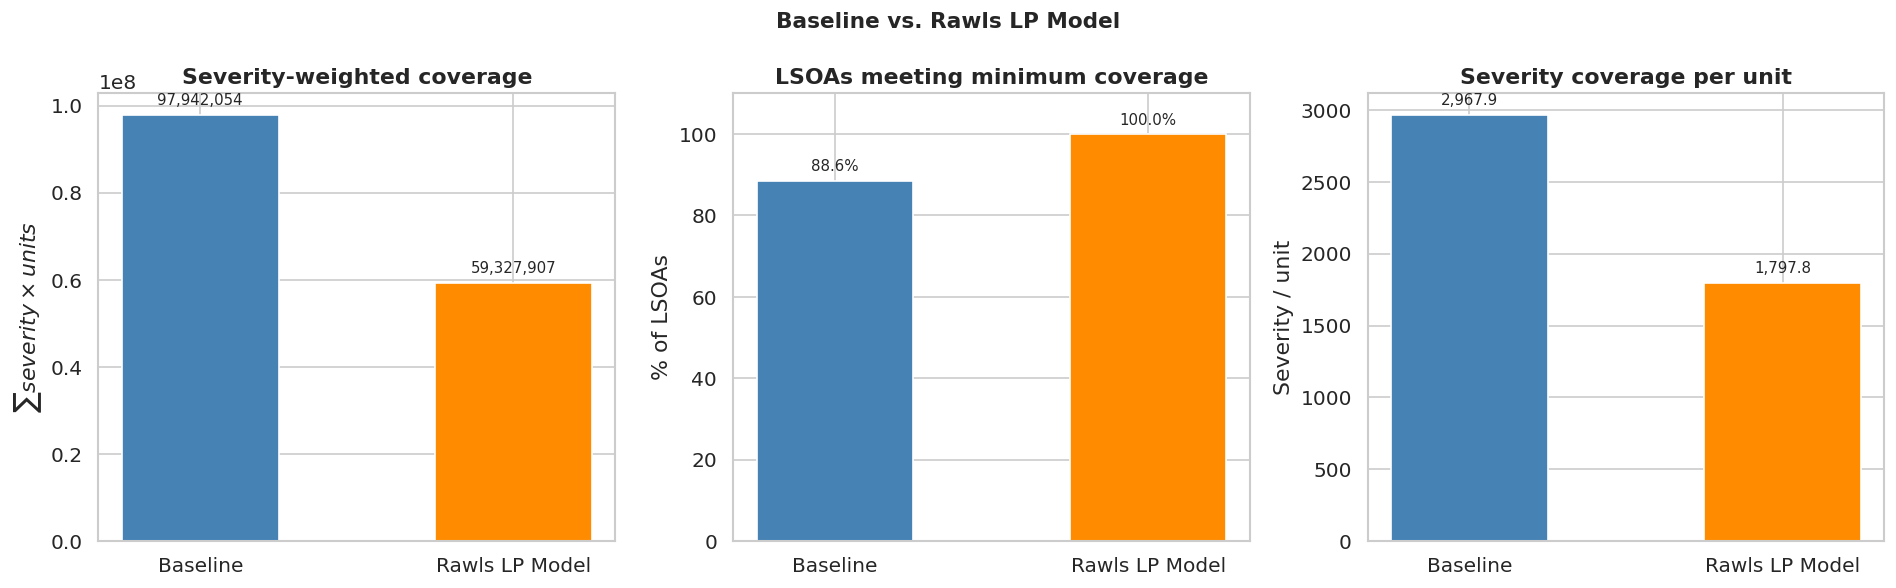

In [116]:
def severity_coverage(alloc, severity) -> float:
    return (severity * alloc).sum()

def min_coverage_rate(alloc, threshold = 2.0) -> float:
    return (alloc >= threshold).mean()

def severity_per_unit(alloc, severity) -> float:
    return (severity * alloc).sum() / alloc.sum()

fig, ax = plt.subplots(1, 3, figsize=(16, 5))

bl_units = lsoa_df["bl_units"]
r_units = lsoa_df["r_units"]

models = ["Baseline", "Rawls LP Model"]
sev_vals = [severity_coverage(bl_units, s), severity_coverage(r_units, s)]
bars = ax[0].bar(models, sev_vals, color=["steelblue", "darkorange"], width=0.5)
ax[0].bar_label(bars, fmt="{:,.0f}", padding=4, fontsize=9)
ax[0].set_title("Severity-weighted coverage", fontweight="bold")
ax[0].set_ylabel("$\\sum severity \\times units$")

cov_vals = [min_coverage_rate(bl_units) * 100, min_coverage_rate(r_units) * 100]
bars = ax[1].bar(models, cov_vals, color=["steelblue", "darkorange"], width=0.5)
ax[1].bar_label(bars, fmt="{:.1f}%", padding=4, fontsize=9)
ax[1].set_ylim(0, 110)
ax[1].set_title("LSOAs meeting minimum coverage", fontweight="bold")
ax[1].set_ylabel("% of LSOAs")

eff_vals = [severity_per_unit(bl_units, s), severity_per_unit(r_units, s)]
bars = ax[2].bar(models, eff_vals, color=["steelblue", "darkorange"], width=0.5)
ax[2].bar_label(bars, fmt="{:,.1f}", padding=4, fontsize=9)
ax[2].set_title("Severity coverage per unit", fontweight="bold")
ax[2].set_ylabel("Severity / unit")

plt.suptitle("Baseline vs. Rawls LP Model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [117]:
import calendar
from datetime import date

_DAILY_HOURLY_WEIGHTS: dict[str, tuple[list[float], list[float]]] = {
    "Violence and sexual offences": (
        [
            2,
            3,
            4,
            4,
            3,
            1,
            1,
            1,
            1,
            1,
            1,
            1,
            1,
            1,
            1,
            2,
            2,
            3,
            4,
            5,
            6,
            7,
            6,
            4,
        ],
        [2, 2, 2, 3, 5, 7, 5],
    ),
    "Burglary": (
        [
            2,
            2,
            2,
            1,
            1,
            1,
            1,
            1,
            1,
            1,
            1,
            1,
            1,
            2,
            3,
            4,
            5,
            6,
            6,
            5,
            4,
            3,
            3,
            2,
        ],
        [4, 4, 4, 4, 3, 3, 4],
    ),
    "Theft from the person": (
        [
            1,
            1,
            1,
            1,
            1,
            1,
            2,
            4,
            5,
            5,
            5,
            5,
            5,
            5,
            5,
            4,
            4,
            3,
            3,
            2,
            2,
            1,
            1,
            1,
        ],
        [4, 4, 4, 4, 4, 5, 4],
    ),
    "Anti-social behaviour": (
        [
            1,
            1,
            1,
            1,
            1,
            1,
            1,
            1,
            2,
            2,
            2,
            2,
            2,
            2,
            3,
            3,
            4,
            5,
            6,
            6,
            5,
            4,
            3,
            2,
        ],
        [3, 3, 3, 4, 5, 6, 5],
    ),
    "Drugs": (
        [1, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 4, 4, 4, 3, 3, 2],
        [3, 3, 3, 4, 5, 5, 4],
    ),
    "Criminal damage and arson": (
        [
            2,
            3,
            3,
            2,
            1,
            1,
            1,
            1,
            1,
            1,
            1,
            1,
            1,
            1,
            2,
            2,
            3,
            4,
            5,
            5,
            4,
            4,
            3,
            2,
        ],
        [3, 3, 3, 4, 5, 6, 4],
    ),
    "Vehicle crime": (
        [2, 3, 4, 3, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 4, 4, 3, 3, 2, 1],
        [4, 4, 4, 4, 4, 5, 4],
    ),
    "Robbery": (
        [1, 2, 2, 2, 1, 1, 1, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 5, 5, 5, 4, 3, 2],
        [3, 3, 3, 4, 5, 5, 4],
    ),
    "Shoplifting": (
        [1, 1, 1, 1, 1, 1, 1, 2, 4, 5, 5, 5, 5, 5, 5, 5, 4, 3, 2, 1, 1, 1, 1, 1],
        [5, 5, 5, 5, 5, 6, 3],
    ),
    "Other crime": (
        [1, 1, 1, 1, 1, 1, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 1, 1],
        [4, 4, 4, 4, 4, 4, 4],
    ),
}


def schedule_units(
    units: int,
    crime_share: dict[str, float],
    year: int,
    month: int,
    active_units=0.33,
    min_units=1,
) -> dict[int, dict[int, int]]:
    if not 0 < active_units <= 1:
        raise ValueError("active_units must be between 0 and 1")
    if units <= 0:
        raise ValueError("units must be >= 1")

    total_crime_share = sum(crime_share.values())
    if total_crime_share == 0:
        raise ValueError("crime_share must contain at least one non-zero value")

    norm = {k: v / total_crime_share for k, v in crime_share.items()}

    num_days = calendar.monthrange(year, month)[1]
    risk = np.zeros((num_days, 24), dtype=float)

    for category, share in norm.items():
        category = category if category in _DAILY_HOURLY_WEIGHTS else "Other crime"

        hourly = np.array(_DAILY_HOURLY_WEIGHTS[category][0], dtype=float)
        hourly /= hourly.sum()

        daily = np.array(_DAILY_HOURLY_WEIGHTS[category][1], dtype=float)
        daily /= daily.sum()

        for d in range(num_days):
            dow = date(year, month, d + 1).weekday()
            risk[d] += share * daily[dow] * hourly

    risk /= risk.mean()
    raw = risk * units * active_units

    units = np.maximum(np.round(raw).astype(int), min_units)

    return {d + 1: {h: int(units[d, h]) for h in range(24)} for d in range(num_days)}

In [120]:
lsoa = "E01004763"
crime_share = {k: v["crime_count"] for k, v in df_raw[df_raw["lsoa_code"] == lsoa][["category", "crime_count"]].set_index("category").to_dict(orient="index").items()}
pd.DataFrame(schedule_units(3_000, crime_share, 2025, 1))

,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
0,457,457,457,457,457,457,457,457,457,457,...,457,457,457,457,457,457,457,457,457,457
1,457,457,457,457,457,457,457,457,457,457,...,457,457,457,457,457,457,457,457,457,457
2,457,457,457,457,457,457,457,457,457,457,...,457,457,457,457,457,457,457,457,457,457
3,457,457,457,457,457,457,457,457,457,457,...,457,457,457,457,457,457,457,457,457,457
4,457,457,457,457,457,457,457,457,457,457,...,457,457,457,457,457,457,457,457,457,457
5,457,457,457,457,457,457,457,457,457,457,...,457,457,457,457,457,457,457,457,457,457
6,914,914,914,914,914,914,914,914,914,914,...,914,914,914,914,914,914,914,914,914,914
7,1371,1371,1371,1371,1371,1371,1371,1371,1371,1371,...,1371,1371,1371,1371,1371,1371,1371,1371,1371,1371
8,1371,1371,1371,1371,1371,1371,1371,1371,1371,1371,...,1371,1371,1371,1371,1371,1371,1371,1371,1371,1371
9,1371,1371,1371,1371,1371,1371,1371,1371,1371,1371,...,1371,1371,1371,1371,1371,1371,1371,1371,1371,1371
